In [2]:
# Install medmnist if needed (run this cell first)
import sys
import numpy as np

# Alternative method: Using medmnist library (no kagglehub needed)
import medmnist
from medmnist import INFO, Evaluator
import torch
import torchvision.transforms as transforms
from torch.utils.data import DataLoader

print("✓ medmnist library available")
print(f"Available datasets: {list(INFO.keys())}")

# Load PneumoniaMNIST dataset
data_flag = 'pneumoniamnist'
download = True

info = INFO[data_flag]
DataClass = getattr(medmnist, info['python_class'])

#Data transformation
data_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[.5], std=[.5]),
    transforms.Lambda(lambda x: x.squeeze(0))
])


#Qiskit
from qiskit import QuantumCircuit


#PennyLane
import pennylane as qml
from pennylane import numpy as pnp


# Load training and validation sets
train_dataset_transformed = DataClass(split='train', transform=data_transform, download=download)
val_dataset_transformed = DataClass(split='val', transform=data_transform, download=download)
test_dataset_transformed = DataClass(split='test', transform=data_transform, download=download)


train_dataset = DataClass(split='train', download=download)
val_dataset = DataClass(split='val', download=download)
test_dataset = DataClass(split='test', download=download)


# future iterations
# use transform with mean and std of the dataset



✓ medmnist library available
Available datasets: ['pathmnist', 'chestmnist', 'dermamnist', 'octmnist', 'pneumoniamnist', 'retinamnist', 'breastmnist', 'bloodmnist', 'tissuemnist', 'organamnist', 'organcmnist', 'organsmnist', 'organmnist3d', 'nodulemnist3d', 'adrenalmnist3d', 'fracturemnist3d', 'vesselmnist3d', 'synapsemnist3d']


In [2]:
len(train_dataset)

4708

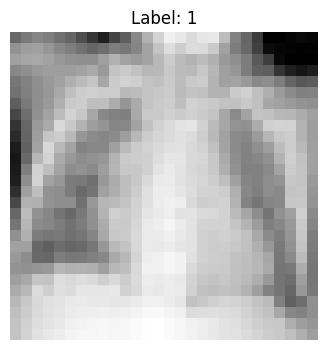

In [2]:
# Display a single image from train_dataset
import matplotlib.pyplot as plt

# Get one sample from the training dataset
image, label = train_dataset[0]

# Convert to numpy array (handles PIL Image, tensor, or array)
image = np.array(image).reshape(28, 28)

# Handle label (extract scalar value if tensor/array)
if isinstance(label, (list, tuple, np.ndarray)):
    label = label[0] if len(label) > 0 else label
elif hasattr(label, 'item'):
    label = label.item()

# Display the image
plt.figure(figsize=(4, 4))
plt.imshow(image, cmap='gray')
plt.axis('off')
plt.title(f'Label: {label}')
plt.show()


In [3]:
def amplitude_encode_2x2_patch(patch_2x2):
    """
    validated

    Amplitude encode a 2x2 patch (4 pixels) into a quantum state vector.
    
    Args:
        patch_2x2: 2x2 array of pixel values (4 pixels total)
    
    Returns:
        normalized amplitude vector for quantum state (16 dimensions for 4 qubits)
        Only first 4 amplitudes are non-zero (representing the 4 pixels)
    """
    # Convert to numpy array and flatten to get 4 pixels
    pixels = np.array(patch_2x2).flatten()
    
    # Ensure we have exactly 4 pixels
    if len(pixels) > 4:
        pixels = pixels[:4]
    elif len(pixels) < 4:
        # Pad with zeros if needed
        pixels = np.pad(pixels, (0, 4 - len(pixels)), mode='constant')
    
    # Normalize: ensure sum of squares equals 1 (quantum state requirement)
    norm = np.linalg.norm(pixels)
    if norm == 0:
        # If all zeros, use uniform superposition for first 4 states
        amplitudes = np.ones(4, dtype=complex) / np.sqrt(4)
    else:
        # Normalize to create valid quantum state
        amplitudes = pixels.astype(complex) / norm
    
    # Pad to 16 dimensions (2^4 = 16 for 4 qubits)
    # Only first 4 amplitudes are non-zero
    state_vector = np.zeros(16, dtype=complex)
    state_vector[:4] = amplitudes
    
    return state_vector

def normalize_image_global(image):
    """
    Normalize an image globally using Min-Max normalization to [0, 1] range.
    
    Formula: normalized = (x - min) / (max - min)
    This scales all pixel values in the image to the range [0, 1] based on
    the global min and max values across the entire image.
    
    Args:
        image: numpy array (2D image)
    
    Returns:
        Normalized image with values in [0, 1] range
    """
    image = np.array(image)
    pixel_min, pixel_max = image.min(), image.max()
    
    if pixel_max > pixel_min:
        # Min-Max normalization: (x - min) / (max - min)
        normalized = (image - pixel_min) / (pixel_max - pixel_min)
    else:
        # If all pixels are the same, return zeros (or could return 0.5)
        normalized = np.zeros_like(image)
    
    return normalized

def extract_2x2_patches(image, normalize=False):
    """
    validated
    
    Extract all 2x2 patches from a 28x28 image with stride 2.
    This gives 14x14 = 196 patches total (since 28/2 = 14 positions per dimension).
    
    Args:
        image: 28x28 numpy array
        normalize: bool, if True, normalize the image globally before extracting patches
    
    Returns:
        List of 2x2 patches (14x14 = 196 patches total)
    """
    # Ensure image is 2D
    image = np.array(image)
    if image.ndim != 2:
        raise ValueError(f"Expected 2D image, got shape {image.shape}")
    
    # Normalize image globally if requested
    if normalize:
        image = normalize_image_global(image)
    
    h, w = image.shape
    patches = []
    
    # Extract 2x2 patches with stride 2
    # Positions: 0, 2, 4, ..., 26 (14 positions per dimension)
    # This gives us 14x14 = 196 patches total
    for i in range(0, h, 2):  # Step by 2: 0, 2, 4, ..., 26
        for j in range(0, w, 2):  # Step by 2: 0, 2, 4, ..., 26
            patch = image[i:i+2, j:j+2]
            # Ensure patch is exactly 2x2 (pad if at edge)
            if patch.shape != (2, 2):
                # Pad to 2x2 if needed (for edge patches)
                patch = np.pad(patch, ((0, 2-patch.shape[0]), (0, 2-patch.shape[1])), mode='constant')
            patches.append(patch)
    
    return patches


In [4]:
# PennyLane Implementation (as per paper)
# Rotation Encoding + Variational Processing Block with RandomLayers ansatz

def create_quantum_device(n_qubits=4, shots=1000):
    """
    Create a PennyLane quantum device.
    
    Args:
        n_qubits: number of qubits (default: 4 for 2x2 patch)
        shots: number of measurement shots
    
    Returns:
        qml.Device: PennyLane quantum device
    """
    # Use default.qubit simulator (can be changed to other backends)
    dev = qml.device('default.qubit', wires=n_qubits, shots=shots)
    return dev

# Create fixed weights for RandomLayers (consistent across all patches)
# Shallow depth for near-term devices (1 layer)
from pennylane.templates import RandomLayers
np.random.seed(42)  # For reproducibility
n_layers = 1  # Shallow depth for near-term devices
n_rotations = 4  # One rotation per qubit per layer
FIXED_RANDOMLAYERS_WEIGHTS = np.random.uniform(0, 2*np.pi, (n_layers, n_rotations))

def rotation_encode_and_variational_processing(patch_2x2, encoding_type='linear', shots=1000):
    """
    Complete quantum processing: Rotation encoding + Variational Processing Block.
    
    Based on the paper:
    1. Rotation encoding: Each pixel encoded onto separate qubit using RY(θ_j) where θ_j = π * x_j
    2. Variational Processing: RandomLayers ansatz (alternating single-qubit rotations + entangling gates)
    3. Measurement: Returns 4 measurement probabilities (one per qubit)
    
    Args:
        patch_2x2: 2x2 array of pixel values (4 pixels total)
        encoding_type: str, type of transformation for rotation encoding
        shots: int, number of measurement shots
    
    Returns:
        numpy array of 4 measurement probabilities (one per qubit)
    """
    # Convert to numpy array and flatten to get 4 pixels
    pixels = np.array(patch_2x2).flatten()
    
    # Ensure we have exactly 4 pixels
    if len(pixels) > 4:
        pixels = pixels[:4]
    elif len(pixels) < 4:
        pixels = np.pad(pixels, (0, 4 - len(pixels)), mode='constant')
    
    # Normalize/clamp pixels to [0, 1] range
    normalized_pixels = np.clip(pixels, 0, 1)
    
    # Create quantum device
    dev = create_quantum_device(n_qubits=4, shots=shots)
    
    @qml.qnode(dev)
    def quantum_circuit(pixel_values, variational_weights):
        """
        Quantum circuit: Rotation encoding + Variational Processing Block
        
        Args:
            pixel_values: array of 4 normalized pixel values [0, 1]
            variational_weights: weights for RandomLayers ansatz
        """
        # Step 1: Rotation Encoding
        # Each pixel encoded onto separate qubit using RY(θ_j) where θ_j = π * x_j
        for j in range(4):
            x_j = pixel_values[j]
            
            if encoding_type == 'linear':
                theta_j = np.pi * x_j  # θ_j = π * x_j (Equation 1)
            elif encoding_type == 'full_circle':
                theta_j = 2 * np.pi * x_j
            elif encoding_type == 'half_range':
                theta_j = np.pi / 2 * x_j
            elif encoding_type == 'arccos':
                theta_j = np.arccos(1 - x_j)
            elif encoding_type == 'sqrt':
                theta_j = np.pi * np.sqrt(x_j)
            else:
                theta_j = np.pi * x_j
            
            qml.RY(theta_j, wires=j)  # Apply RY(θ_j) to qubit j
        
        # Step 2: Variational Processing Block
        # Use PennyLane's RandomLayers ansatz (as per paper)
        # This consists of alternating layers of single-qubit rotations and entangling gates
        # Default parameters for 4-qubit system (shallow depth for near-term devices)
        RandomLayers(weights=variational_weights, wires=range(4), seed=42)
        
        # Step 3: Measurement
        # Return expectation values or probabilities for each qubit
        return [qml.expval(qml.PauliZ(wires=i)) for i in range(4)]
    
    # Run the quantum circuit with fixed variational weights
    expectations = quantum_circuit(normalized_pixels, FIXED_RANDOMLAYERS_WEIGHTS)
    
    # Convert expectation values to probabilities
    # expval(PauliZ) = P(0) - P(1), so P(1) = (1 - expval) / 2
    # We'll use the probability of measuring |1> for each qubit
    probs = np.array([(1 - exp_val) / 2 for exp_val in expectations])
    
    # Ensure probabilities are in [0, 1] range
    probs = np.clip(probs, 0, 1)
    
    return probs

def get_all_rotation_circuits_pennylane(image, normalize=True, encoding_type='sqrt', shots=1000):
    """
    Full pipeline using PennyLane: Extract patches, encode, process with variational circuit, 
    and reconstruct quantum feature map.
    
    Process:
    1. Extract all 2x2 patches (14x14 = 196 patches)
    2. For each patch: Rotation encoding + Variational Processing Block (RandomLayers)
    3. Measure to get 4 values per patch
    4. Organize into 14x14x4 quantum feature map
    
    Args:
        image: 28x28 numpy array
        normalize: bool, if True, normalize image globally before extracting patches
        encoding_type: str, type of transformation for rotation encoding
        shots: int, number of measurement shots
    
    Returns:
        numpy array of shape (14, 14, 4) - quantum feature map
    """
    # Extract all 2x2 patches (with optional global normalization)
    patches = extract_2x2_patches(image, normalize=normalize)
    
    # Process each patch through quantum circuit
    quantum_features = []
    
    for patch in patches:
        # Rotation encoding + Variational processing + Measurement
        features = rotation_encode_and_variational_processing(
            patch, 
            encoding_type=encoding_type, 
            shots=shots
        )
        quantum_features.append(features)
    
    # Reshape to 14x14x4 (14x14 patches, each with 4 features)
    num_patches = len(quantum_features)
    spatial_dim = int(np.sqrt(num_patches))  # Should be 14
    quantum_feature_map = np.array(quantum_features).reshape(spatial_dim, spatial_dim, 4)
    
    return quantum_feature_map

print("✓ PennyLane quantum processing functions defined")
print("  - rotation_encode_and_variational_processing(): Rotation encoding + RandomLayers ansatz")
print("  - get_all_rotation_circuits_pennylane(): Full pipeline with variational processing")


✓ PennyLane quantum processing functions defined
  - rotation_encode_and_variational_processing(): Rotation encoding + RandomLayers ansatz
  - get_all_rotation_circuits_pennylane(): Full pipeline with variational processing


In [5]:
# Step 1: Process ALL images in train_dataset to quantum feature maps
# This converts each 28x28 image into a 14x14x4 quantum feature map

import sys
!{sys.executable} -m pip install tqdm --quiet
from tqdm import tqdm

def process_all_images_to_quantum(dataset, normalize=True, encoding_type='linear', shots=1000, verbose=True):
    """
    Process all images in a dataset through quantum circuits to create quantum feature maps.
    
    Args:
        dataset: medmnist dataset containing (image, label) tuples
        normalize: bool, if True, normalize images globally before extracting patches
        encoding_type: str, type of transformation for rotation encoding
        shots: int, number of measurement shots for quantum circuits
        verbose: bool, if True, show progress bar
    
    Returns:
        tuple: (quantum_features, labels) as numpy arrays
            - quantum_features: shape (num_images, 14, 14, 4)
            - labels: shape (num_images,)
    """
    quantum_features = []
    labels = []
    processed_images = 0
    
    # Create iterator with progress bar if verbose
    iterator = tqdm(dataset, desc="Processing images to quantum feature maps") if verbose else dataset
    for image, label in iterator:
        
        # Convert image to numpy if needed
        if isinstance(image, torch.Tensor):
            image_np = image.numpy()
        else:
            image_np = np.array(image)
        
        # Ensure image is 2D (28x28)
        if image_np.ndim > 2:
            image_np = image_np.squeeze()
        image_np = image_np.reshape(28, 28)
        
        if processed_images <= 10:

            # Process image through quantum circuit → 14x14x4 quantum feature map
            quantum_feature_map = get_all_rotation_circuits_pennylane(
                image_np, 
                normalize=normalize, 
                encoding_type=encoding_type, 
                shots=shots
            )
            
            # Store quantum feature map and label
            quantum_features.append(quantum_feature_map)
            processed_images += 1
            print("Done with image", processed_images)
            
            # Handle label (could be tensor, array, or scalar)
            if isinstance(label, torch.Tensor):
                label_val = label.item() if label.numel() == 1 else label.numpy()
            elif isinstance(label, (list, tuple, np.ndarray)):
                label_val = label[0] if len(label) > 0 else label
            else:
                label_val = label
            
            labels.append(label_val)
    
    # Convert to numpy arrays (TensorFlow/Keras compatible)
    quantum_features = np.array(quantum_features, dtype=np.float32)
    labels = np.array(labels, dtype=np.float32)  # Binary classification: 0 or 1
    
    return quantum_features, labels

def save_quantum_dataset(quantum_features, labels, filepath='quantum_train_dataset.npz'):
    """Save quantum dataset to disk (numpy format for TensorFlow)."""
    np.savez(filepath, quantum_features=quantum_features, labels=labels)
    print(f"✓ Quantum dataset saved to {filepath}")

def load_quantum_dataset(filepath='quantum_train_dataset.npz'):
    """Load quantum dataset from disk."""
    data = np.load(filepath)
    quantum_features = data['quantum_features']
    labels = data['labels']
    print(f"✓ Quantum dataset loaded from {filepath}")
    print(f"  Dataset size: {len(quantum_features)}")
    print(f"  Feature map shape: {quantum_features[0].shape}")
    return quantum_features, labels

print("✓ Dataset processing functions defined")
print("  - process_all_images_to_quantum(): Process entire dataset → quantum feature maps")
print("  - save_quantum_dataset() / load_quantum_dataset(): Save/load functionality")


✓ Dataset processing functions defined
  - process_all_images_to_quantum(): Process entire dataset → quantum feature maps
  - save_quantum_dataset() / load_quantum_dataset(): Save/load functionality


In [6]:
# Process all training images to quantum feature maps
# NOTE: This will take a significant amount of time!
# Each image requires processing 196 patches (14x14) through quantum circuits
# For ~4708 training images, this could take 2-3 hours

print("="*60)
print("STEP 1: Processing all training images to quantum feature maps")
print("="*60)
print(f"Total images in train_dataset: {len(train_dataset)}")
print("This may take a while - processing 196 quantum circuits per image...")
print("Estimated time: ~{:.1f} hours (assuming ~2 seconds per image)".format(len(train_dataset) * 2 / 3600))
print()

# Process the entire training dataset
quantum_train_features, quantum_train_labels = process_all_images_to_quantum(
    train_dataset,
    normalize=True,
    encoding_type='linear',  # As per paper: θ_j = π * x_j
    shots=1000,
    verbose=True
)

print("\n" + "="*60)
print("Processing Complete!")
print("="*60)
print(f"✓ Processed {len(quantum_train_features)} images")
print(f"  Quantum features shape: {quantum_train_features.shape}")
print(f"  Labels shape: {quantum_train_labels.shape}")
print(f"  Feature map shape per image: {quantum_train_features[0].shape}")
print(f"  Data type: {quantum_train_features.dtype} (TensorFlow compatible)")

# Save the quantum dataset to avoid reprocessing
# save_quantum_dataset(quantum_train_features, quantum_train_labels, 'quantum_train_dataset.npz')
# print("\n💡 Tip: Next time, you can load the dataset with:")
# print("   quantum_train_features, quantum_train_labels = load_quantum_dataset('quantum_train_dataset.npz')")


STEP 1: Processing all training images to quantum feature maps
Total images in train_dataset: 4708
This may take a while - processing 196 quantum circuits per image...
Estimated time: ~2.6 hours (assuming ~2 seconds per image)



Processing images to quantum feature maps:   0%|          | 0/4708 [00:00<?, ?it/s]/Users/eldana/Documents/Quantum/msc_venv/lib/python3.13/site-packages/pennylane/devices/device_api.py:193: PennyLaneDeprecationWarning: Setting shots on device is deprecated. Please use the `set_shots` transform on the respective QNode instead.
  warnings.warn(
Processing images to quantum feature maps:   0%|          | 1/4708 [00:00<20:53,  3.75it/s]

Done with image 1


Processing images to quantum feature maps:   0%|          | 2/4708 [00:00<19:45,  3.97it/s]

Done with image 2


...

Done with image 9


Processing images to quantum feature maps:   0%|          | 10/4708 [00:02<19:14,  4.07it/s]

Done with image 10


Processing images to quantum feature maps: 100%|██████████| 4708/4708 [00:02<00:00, 1633.76it/s]

Done with image 11

Processing Complete!
✓ Processed 11 images
  Quantum features shape: (11, 14, 14, 4)
  Labels shape: (11,)
  Feature map shape per image: (14, 14, 4)
  Data type: float32 (TensorFlow compatible)


In [7]:
# Step 2: Create TensorFlow/Keras Hybrid Neural Network Model
# Architecture as per paper: Quanvolutional Layer + Classical Feedforward Network


import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models

print("✓ TensorFlow installed and imported")
print(f"TensorFlow version: {tf.__version__}")

def create_hybrid_quantum_classical_model(input_shape=(14, 14, 4)):
    """
    Create hybrid quantum-classical neural network architecture.
    
    Architecture (as per paper):
    1. Input: Quantum feature maps from quanvolutional layer (14x14x4)
    2. Flatten layer: Flatten quantum feature maps
    3. Dense layer: 128 units with ReLU activation
    4. Output layer: Dense layer with sigmoid activation for binary classification
    
    Args:
        input_shape: tuple, shape of input quantum feature maps (default: 14x14x4)
    
    Returns:
        keras.Model: Compiled model ready for training
    """
    # Create model
    model = models.Sequential([
        # Input layer (quantum feature maps from quanvolutional processing)
        layers.Input(shape=input_shape),
        
        # Flatten quantum feature maps
        layers.Flatten(name='flatten_layer'),
        
        # Fully connected dense layer with ReLU activation
        layers.Dense(128, activation='relu', name='dense_layer'),
        
        # Output layer with sigmoid activation for binary classification
        layers.Dense(1, activation='sigmoid', name='output_layer')
    ])
    
    # Compile model (as per paper)
    # Adam optimizer and binary cross-entropy loss
    model.compile(
        optimizer='adam',
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    
    return model

# Create the model
model = create_hybrid_quantum_classical_model(input_shape=(14, 14, 4))

# Display model architecture
print("\n" + "="*60)
print("Hybrid Quantum-Classical Neural Network Architecture")
print("="*60)
model.summary()
print("="*60)
print("\nModel Configuration (as per paper):")
print("  - Optimizer: Adam")
print("  - Loss: Binary Cross-Entropy")
print("  - Architecture: Flatten → Dense(128, ReLU) → Dense(1, Sigmoid)")
print("="*60)


✓ TensorFlow installed and imported
TensorFlow version: 2.20.0

Hybrid Quantum-Classical Neural Network Architecture


/Users/eldana/Documents/Quantum/msc_venv/lib/python3.13/site-packages/keras/src/export/tf2onnx_lib.py:8: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, "object"):


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_layer (Flatten)         │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_layer (Dense)             │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer (Dense)            │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 100,609 (393.00 KB)

 Trainable params: 100,609 (393.00 KB)

 Non-trainable params: 0 (0.00 B)


Model Configuration (as per paper):
  - Optimizer: Adam
  - Loss: Binary Cross-Entropy
  - Architecture: Flatten → Dense(128, ReLU) → Dense(1, Sigmoid)


In [8]:
# Step 3: Train the Hybrid Quantum-Classical Model
# Load quantum training dataset (or use if already processed in cell 5)

# Load quantum training dataset
try:
    # Check if variables already exist (from cell 5)
    if 'quantum_train_features' not in globals() or 'quantum_train_labels' not in globals():
        print("Loading quantum training dataset from file...")
        quantum_train_features, quantum_train_labels = load_quantum_dataset('quantum_train_dataset.npz')
    else:
        print("Using quantum training dataset from previous cell...")
except:
    print("⚠️  quantum_train_features and quantum_train_labels not found!")
    print("   Please run cell 5 first to process the training dataset")

# Process validation dataset
print("\n" + "="*60)
print("Processing validation dataset...")
print("="*60)
quantum_val_features, quantum_val_labels = process_all_images_to_quantum(
    val_dataset,
    normalize=True,
    encoding_type='linear',
    shots=1000,
    verbose=True
)

# Save validation dataset
save_quantum_dataset(quantum_val_features, quantum_val_labels, 'quantum_val_dataset.npz')

# Training configuration (as per paper)
print("\n" + "="*60)
print("Training Configuration")
print("="*60)
print(f"Training samples: {len(quantum_train_features)}")
print(f"Validation samples: {len(quantum_val_features)}")
print(f"Input shape: {quantum_train_features[0].shape}")
print(f"Batch size: 4 (as per paper)")
print(f"Epochs: 10 (as per paper)")
print(f"Optimizer: Adam (as per paper)")
print(f"Loss: Binary Cross-Entropy (as per paper)")
print("="*60)

# Train the model using TensorFlow/Keras
print("\nStarting training...")
history = model.fit(
    quantum_train_features,
    quantum_train_labels,
    batch_size=4,  # As per paper
    epochs=10,      # As per paper
    validation_data=(quantum_val_features, quantum_val_labels),
    verbose=1
)

print("\n" + "="*60)
print("Training Completed!")
print("="*60)
print(f"Final training accuracy: {history.history['accuracy'][-1]:.4f}")
print(f"Final validation accuracy: {history.history['val_accuracy'][-1]:.4f}")
print(f"Final training loss: {history.history['loss'][-1]:.4f}")
print(f"Final validation loss: {history.history['val_loss'][-1]:.4f}")
print("="*60)


Using quantum training dataset from previous cell...

Processing validation dataset...


Processing images to quantum feature maps:   0%|          | 1/524 [00:00<02:13,  3.93it/s]

Done with image 1


Processing images to quantum feature maps:   0%|          | 2/524 [00:00<02:09,  4.03it/s]

Done with image 2


...

Processing images to quantum feature maps:   2%|▏         | 10/524 [00:02<02:11,  3.92it/s]

Done with image 10


Processing images to quantum feature maps: 100%|██████████| 524/524 [00:02<00:00, 187.86it/s]

Done with image 11
✓ Quantum dataset saved to quantum_val_dataset.npz

Training Configuration
Training samples: 11
Validation samples: 11
Input shape: (14, 14, 4)
Batch size: 4 (as per paper)
Epochs: 10 (as per paper)
Optimizer: Adam (as per paper)
Loss: Binary Cross-Entropy (as per paper)

Starting training...
Epoch 1/10


3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - accuracy: 0.8182 - loss: 0.7098 - val_accuracy: 0.8182 - val_loss: 0.5215
Epoch 2/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.8182 - loss: 0.4449 - val_accuracy: 0.9091 - val_loss: 0.5654
Epoch 3/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9091 - loss: 0.3316 - val_accuracy: 0.8182 - val_loss: 0.4077
Epoch 4/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9091 - loss: 0.2036 - val_accuracy: 0.8182 - val_loss: 0.4108
Epoch 5/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9091 - loss: 0.1722 - val_accuracy: 0.8182 - val_loss: 0.4037
Epoch 6/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 1.0000 - loss: 0.1278 - val_accuracy: 0.7273 - val_loss: 0.4124
Epoch 7/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 1.0000 - loss: 0.1089 - val_accuracy: 0.6364 - val_loss: 0.4307
Epoch 8/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 1.0000 - loss: 0.0886 - val_accuracy: 0.7273 - val_loss: 0.3912
Epoch 9/10
3/3 ━━

In [4]:
# QIR (Quantum Image Representation) Implementation
# Based on: Pandey & Mandal (2026) - QAttn-CNN paper
# Implements separate position and intensity encoding for 28×28 grayscale images

def calculate_qir_qubits(image_size=28):
    """
    Calculate qubit requirements for QIR encoding.
    
    According to QIR: Position is encoded as |x⟩|y⟩ where:
    - |x⟩: row index, requires ⌈log₂(N)⌉ qubits
    - |y⟩: column index, requires ⌈log₂(N)⌉ qubits
    - Total position qubits: 2×⌈log₂(N)⌉ = ⌈log₂(N²)⌉
    
    Args:
        image_size: Size of square image (default: 28 for 28×28)
    
    Returns:
        tuple: (x_qubits, y_qubits, total_position_qubits, total_pixels)
    """
    total_pixels = image_size * image_size
    # Each of x and y requires ⌈log₂(image_size)⌉ qubits
    x_qubits = int(np.ceil(np.log2(image_size)))
    y_qubits = int(np.ceil(np.log2(image_size)))
    total_position_qubits = x_qubits + y_qubits
    return x_qubits, y_qubits, total_position_qubits, total_pixels

def encode_position_to_binary(x, y, image_size=28):
    """
    Encode pixel position (x, y) into separate binary representations.
    
    According to QIR: Position is |x⟩|y⟩ where x and y are encoded separately.
    
    Args:
        x: Row index [0, image_size-1]
        y: Column index [0, image_size-1]
        image_size: Size of square image
    
    Returns:
        tuple: (x_binary, y_binary) - binary representations of x and y
    """
    # Ensure x and y are within valid range
    x = int(np.clip(x, 0, image_size - 1))
    y = int(np.clip(y, 0, image_size - 1))
    
    # x and y are already in the correct range [0, image_size-1]
    # They will be encoded as binary in the quantum circuit
    return x, y

def binary_to_position(x_binary, y_binary, image_size=28):
    """
    Decode binary position values back to (x, y) coordinates.
    
    Args:
        x_binary: Binary representation of row index
        y_binary: Binary representation of column index
        image_size: Size of square image
    
    Returns:
        tuple: (x, y) coordinates
    """
    x = int(x_binary) % image_size
    y = int(y_binary) % image_size
    return x, y

def prepare_qir_state_frqi(image, normalize=True):
    """
    Prepare QIR state using FRQI (amplitude encoding) for intensity.
    
    According to QIR Equation (7): |I⟩ = (1/√N) Σ(x,y) I(x,y) |x⟩|y⟩
    - Position encoded as |x⟩|y⟩ (separate row and column registers)
    - Intensity I(x,y) encoded in amplitude of |x⟩|y⟩ state
    
    Args:
        image: 28×28 numpy array (grayscale)
        normalize: If True, normalize image to [0, 1]
    
    Returns:
        numpy array: Amplitude-encoded state vector of size 2^(total_position_qubits)
    """
    image = np.array(image)
    image_size = image.shape[0]
    x_qubits, y_qubits, total_position_qubits, total_pixels = calculate_qir_qubits(image_size)
    
    # Normalize image to [0, 1] if needed
    if normalize:
        img_min, img_max = image.min(), image.max()
        if img_max > img_min:
            image = (image - img_min) / (img_max - img_min)
        else:
            image = np.zeros_like(image)
    
    # Create amplitude-encoded state vector
    # State vector index corresponds to |x⟩|y⟩ where:
    # - First x_qubits represent |x⟩
    # - Next y_qubits represent |y⟩
    # - Index = x * 2^y_qubits + y (or equivalently, flattened position)
    state_vector = np.zeros(2**total_position_qubits, dtype=complex)
    
    # Fill state vector: each |x⟩|y⟩ state gets amplitude = I(x,y)
    for x in range(image_size):
        for y in range(image_size):
            # Calculate state index: |x⟩|y⟩ = |x⟩ ⊗ |y⟩
            # Index = x * 2^y_qubits + y
            state_index = x * (2**y_qubits) + y
            state_vector[state_index] = image[x, y]
    
    # Normalize to ensure valid quantum state (sum of |amplitude|^2 = 1)
    # According to QIR: |I⟩ = (1/√N) Σ(x,y) I(x,y) |x⟩|y⟩
    # The state vector must be normalized so that ⟨I|I⟩ = 1
    norm = np.linalg.norm(state_vector)
    if norm > 0:
        state_vector = state_vector / norm
    else:
        # If all zeros, create uniform superposition
        state_vector[:total_pixels] = 1.0 / np.sqrt(total_pixels)
    
    return state_vector, x_qubits, y_qubits, total_position_qubits

def prepare_qir_state_neqr(image, intensity_qubits=8, normalize=True):
    """
    Prepare QIR state using NEQR (binary encoding) for intensity.
    
    According to QIR Equation (9): |I⟩ = (1/√N) Σ(x,y) Σ(i) I_i(x,y) |x⟩|y⟩|i⟩
    - Position encoded as |x⟩|y⟩ (separate row and column registers)
    - Intensity encoded as |I_{x,y}⟩ in binary form (intensity_qubits)
    
    Args:
        image: 28×28 numpy array (grayscale)
        intensity_qubits: Number of qubits for binary intensity encoding (default: 8 for 0-255)
        normalize: If True, normalize image to [0, 1] then scale to [0, 2^intensity_qubits-1]
    
    Returns:
        dict: Dictionary mapping (x, y) tuple to intensity (int, binary representation)
    """
    image = np.array(image)
    image_size = image.shape[0]
    x_qubits, y_qubits, total_position_qubits, total_pixels = calculate_qir_qubits(image_size)
    
    # Normalize and scale to binary range
    if normalize:
        img_min, img_max = image.min(), image.max()
        if img_max > img_min:
            image = (image - img_min) / (img_max - img_min)
        else:
            image = np.zeros_like(image)
    
    # Scale to [0, 2^intensity_qubits - 1] for binary encoding
    max_intensity = 2**intensity_qubits - 1
    intensity_values = (image * max_intensity).astype(int)
    
    # Create mapping: (x, y) -> intensity (binary)
    qir_state = {}
    for x in range(image_size):
        for y in range(image_size):
            intensity = int(intensity_values[x, y])
            qir_state[(x, y)] = intensity
    
    return qir_state, x_qubits, y_qubits, total_position_qubits, intensity_qubits

def create_qir_circuit_frqi(image, shots=1000):
    """
    Create PennyLane quantum circuit for QIR with FRQI (amplitude) intensity encoding.
    
    According to QIR Equation (7): |I⟩ = (1/√N) Σ(x,y) I(x,y) |x⟩|y⟩
    - Position: |x⟩|y⟩ (x_qubits for row, y_qubits for column)
    - Intensity: I(x,y) in amplitudes
    
    Args:
        image: 28×28 numpy array (grayscale)
        shots: Number of measurement shots
    
    Returns:
        tuple: (qml.QNode, state_vector, x_qubits, y_qubits, total_position_qubits)
    """
    x_qubits, y_qubits, total_position_qubits, total_pixels = calculate_qir_qubits(28)
    
    # Prepare amplitude-encoded state
    state_vector, x_q, y_q, pos_q = prepare_qir_state_frqi(image, normalize=True)
    
    # Create quantum device
    dev = qml.device('default.qubit', wires=total_position_qubits, shots=shots)
    
    @qml.qnode(dev)
    def qir_circuit():
        """
        QIR circuit with FRQI: |x⟩|y⟩ position, intensity in amplitudes.
        """
        # Initialize state vector (amplitude encoding)
        # State vector encodes |x⟩|y⟩ where first x_qubits = |x⟩, next y_qubits = |y⟩
        qml.StatePrep(state_vector, wires=range(total_position_qubits))
        
        # Measure all qubits to get position distribution
        return [qml.expval(qml.PauliZ(wires=i)) for i in range(total_position_qubits)]
    
    return qir_circuit, state_vector, x_qubits, y_qubits, total_position_qubits

def create_qir_circuit_neqr(image, intensity_qubits=8, shots=1000):
    """
    Create PennyLane quantum circuit for QIR with NEQR (binary) intensity encoding.
    
    According to QIR Equation (9): |I⟩ = (1/√N) Σ(x,y) Σ(i) I_i(x,y) |x⟩|y⟩|i⟩
    - Position: |x⟩|y⟩ (x_qubits for row, y_qubits for column)
    - Intensity: |I_{x,y}⟩ in binary form (intensity_qubits)
    
    Args:
        image: 28×28 numpy array (grayscale)
        intensity_qubits: Number of qubits for binary intensity (default: 8)
        shots: Number of measurement shots
    
    Returns:
        tuple: (qml.QNode, qir_state, x_qubits, y_qubits, total_position_qubits, intensity_qubits)
    """
    x_qubits, y_qubits, total_position_qubits, total_pixels = calculate_qir_qubits(28)
    total_qubits = total_position_qubits + intensity_qubits
    
    # Prepare NEQR state ((x, y) -> intensity mapping)
    qir_state, x_q, y_q, pos_q, int_q = prepare_qir_state_neqr(image, intensity_qubits, normalize=True)
    
    # Create quantum device
    dev = qml.device('default.qubit', wires=total_qubits, shots=shots)
    
    @qml.qnode(dev)
    def qir_circuit():
        """
        QIR circuit with NEQR: |x⟩|y⟩|i⟩ where |x⟩|y⟩ is position, |i⟩ is intensity in binary.
        """
        # Position register: |x⟩|y⟩
        # First x_qubits: |x⟩ (row index)
        # Next y_qubits: |y⟩ (column index)
        # Create equal superposition of all positions for demonstration
        for i in range(total_position_qubits):
            qml.Hadamard(wires=i)
        
        # Intensity register: |I_{x,y}⟩ (binary representation)
        # This is a simplified version - full implementation would use controlled operations
        # to set intensity based on measured position |x⟩|y⟩
        # For now, prepare intensity register in |0⟩ state
        # (In full implementation, controlled gates would set intensity based on position)
        
        # Measure position and intensity registers
        return [qml.expval(qml.PauliZ(wires=i)) for i in range(total_qubits)]
    
    return qir_circuit, qir_state, x_qubits, y_qubits, total_position_qubits, intensity_qubits

def process_image_qir_frqi(image, shots=1000):
    """
    Process a 28×28 image using QIR with FRQI encoding.
    
    Args:
        image: 28×28 numpy array (grayscale)
        shots: Number of measurement shots
    
    Returns:
        dict: Results including state vector and measurements
    """
    x_qubits, y_qubits, total_position_qubits, total_pixels = calculate_qir_qubits(28)
    
    # Create circuit
    circuit, state_vector, x_q, y_q, pos_q = create_qir_circuit_frqi(image, shots=shots)
    
    # Execute circuit
    measurements = circuit()
    
    # Calculate probabilities from state vector
    probabilities = np.abs(state_vector)**2
    
    return {
        'state_vector': state_vector,
        'probabilities': probabilities,
        'measurements': measurements,
        'x_qubits': x_qubits,
        'y_qubits': y_qubits,
        'total_position_qubits': total_position_qubits,
        'total_pixels': total_pixels
    }

def process_image_qir_neqr(image, intensity_qubits=8, shots=1000):
    """
    Process a 28×28 image using QIR with NEQR encoding.
    
    Args:
        image: 28×28 numpy array (grayscale)
        intensity_qubits: Number of qubits for binary intensity
        shots: Number of measurement shots
    
    Returns:
        dict: Results including position-intensity mapping and measurements
    """
    x_qubits, y_qubits, total_position_qubits, total_pixels = calculate_qir_qubits(28)
    
    # Create circuit
    circuit, qir_state, x_q, y_q, pos_q, int_q = create_qir_circuit_neqr(image, intensity_qubits, shots=shots)
    
    # Execute circuit
    measurements = circuit()
    
    return {
        'qir_state': qir_state,  # (x, y) -> intensity mapping
        'measurements': measurements,
        'x_qubits': x_qubits,
        'y_qubits': y_qubits,
        'total_position_qubits': total_position_qubits,
        'intensity_qubits': intensity_qubits,
        'total_qubits': total_position_qubits + intensity_qubits,
        'total_pixels': total_pixels
    }

# Test with a sample image
print("✓ QIR (Quantum Image Representation) functions defined")
x_q, y_q, pos_q, total_pix = calculate_qir_qubits(28)
print(f"  - Position encoding for 28×28 image: |x⟩|y⟩")
print(f"    • |x⟩ (row): {x_q} qubits")
print(f"    • |y⟩ (column): {y_q} qubits")
print(f"    • Total position qubits: {pos_q} qubits")
print(f"  - Total pixels: {total_pix} pixels")
print("  - FRQI encoding: |I⟩ = (1/√N) Σ(x,y) I(x,y) |x⟩|y⟩ (intensity in amplitudes)")
print("  - NEQR encoding: |I⟩ = (1/√N) Σ(x,y) Σ(i) I_i(x,y) |x⟩|y⟩|i⟩ (intensity in binary)")

# Example usage with a sample image
sample_image, _ = train_dataset[0]
sample_image = np.array(sample_image).reshape(28, 28)

print(f"\nTesting QIR-FRQI on sample image (shape: {sample_image.shape})...")
qir_frqi_result = process_image_qir_frqi(sample_image, shots=1000)
print(f"  ✓ FRQI: State vector size = {len(qir_frqi_result['state_vector'])}")
print(f"  ✓ FRQI: Position qubits = {qir_frqi_result['total_position_qubits']} (|x⟩: {qir_frqi_result['x_qubits']}, |y⟩: {qir_frqi_result['y_qubits']})")

print(f"\nTesting QIR-NEQR on sample image...")
qir_neqr_result = process_image_qir_neqr(sample_image, intensity_qubits=8, shots=1000)
print(f"  ✓ NEQR: Total qubits = {qir_neqr_result['total_qubits']}")
print(f"  ✓ NEQR: Position qubits = {qir_neqr_result['total_position_qubits']} (|x⟩: {qir_neqr_result['x_qubits']}, |y⟩: {qir_neqr_result['y_qubits']})")
print(f"  ✓ NEQR: Intensity qubits = {qir_neqr_result['intensity_qubits']}")
print(f"  ✓ NEQR: Encoded {len(qir_neqr_result['qir_state'])} pixel positions")

✓ QIR (Quantum Image Representation) functions defined
  - Position encoding for 28×28 image: |x⟩|y⟩
    • |x⟩ (row): 5 qubits
    • |y⟩ (column): 5 qubits
    • Total position qubits: 10 qubits
  - Total pixels: 784 pixels
  - FRQI encoding: |I⟩ = (1/√N) Σ(x,y) I(x,y) |x⟩|y⟩ (intensity in amplitudes)
  - NEQR encoding: |I⟩ = (1/√N) Σ(x,y) Σ(i) I_i(x,y) |x⟩|y⟩|i⟩ (intensity in binary)

Testing QIR-FRQI on sample image (shape: (28, 28))...
  ✓ FRQI: State vector size = 1024
  ✓ FRQI: Position qubits = 10 (|x⟩: 5, |y⟩: 5)

Testing QIR-NEQR on sample image...
  ✓ NEQR: Total qubits = 18
  ✓ NEQR: Position qubits = 10 (|x⟩: 5, |y⟩: 5)
  ✓ NEQR: Intensity qubits = 8
  ✓ NEQR: Encoded 784 pixel positions


In [9]:
def visualize_quantum_feature_map(quantum_feature_map, title="Quantum Feature Map (14x14x4)", figsize=(12, 3)):
    """
    Visualize the 14x14x4 quantum feature map.
    
    Displays each of the 4 feature channels (one per qubit) as separate 2D heatmaps.
    
    Args:
        quantum_feature_map: numpy array of shape (14, 14, 4)
        title: str, main title for the plot
        figsize: tuple, figure size (width, height)
    """
    import matplotlib.pyplot as plt
    
    # Ensure the input is the correct shape
    if quantum_feature_map.shape != (14, 14, 4):
        raise ValueError(f"Expected shape (14, 14, 4), got {quantum_feature_map.shape}")
    
    # Create figure with 4 subplots (one for each feature channel)
    fig, axes = plt.subplots(1, 4, figsize=figsize)
    fig.suptitle(title, fontsize=14, fontweight='bold')
    
    # Plot each of the 4 feature channels
    for i in range(4):
        ax = axes[i]
        im = ax.imshow(quantum_feature_map[:, :, i], cmap='viridis', aspect='auto', vmin=0, vmax=1)
        ax.set_title(f'Qubit {i} Features', fontsize=10)
        ax.set_xlabel('Width (patches)')
        if i == 0:
            ax.set_ylabel('Height (patches)')
        ax.set_xticks(range(0, 14, 2))
        ax.set_yticks(range(0, 14, 2))
        
        # Add colorbar
        plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    
    plt.tight_layout()
    plt.show()
    
    # Print summary statistics
    print("\nQuantum Feature Map Statistics:")
    print("=" * 50)
    print(f"Shape: {quantum_feature_map.shape}")
    print(f"Min value: {quantum_feature_map.min():.4f}")
    print(f"Max value: {quantum_feature_map.max():.4f}")
    print(f"Mean value: {quantum_feature_map.mean():.4f}")
    print(f"Std value: {quantum_feature_map.std():.4f}")
    print("\nPer-channel statistics:")
    for i in range(4):
        channel = quantum_feature_map[:, :, i]
        print(f"  Channel {i} (Qubit {i}): min={channel.min():.4f}, max={channel.max():.4f}, "
              f"mean={channel.mean():.4f}, std={channel.std():.4f}")

print("✓ Visualization function defined: visualize_quantum_feature_map()")


✓ Visualization function defined: visualize_quantum_feature_map()


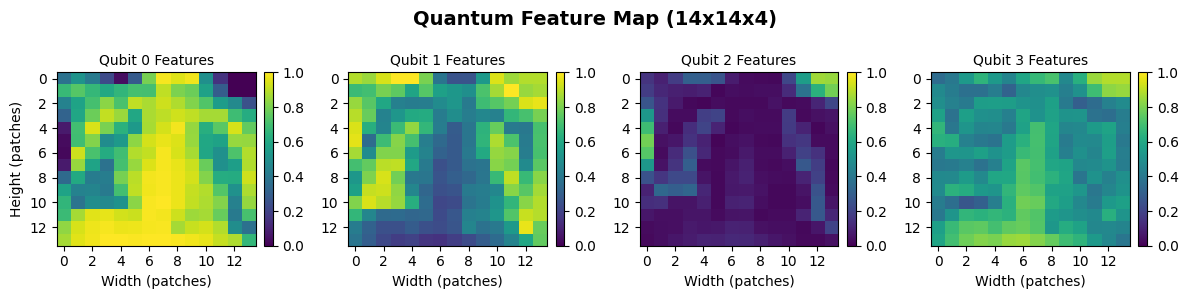


Quantum Feature Map Statistics:
Shape: (14, 14, 4)
Min value: 0.0000
Max value: 1.0000
Mean value: 0.4944
Std value: 0.3029

Per-channel statistics:
  Channel 0 (Qubit 0): min=0.0000, max=1.0000, mean=0.7303, std=0.2520
  Channel 1 (Qubit 1): min=0.1460, max=1.0000, mean=0.5789, std=0.2346
  Channel 2 (Qubit 2): min=0.0150, max=0.8580, mean=0.1188, std=0.1567
  Channel 3 (Qubit 3): min=0.2660, max=0.8850, mean=0.5494, std=0.1302


In [10]:

visualize_quantum_feature_map(quantum_train_features[0])

1. Quanvolutional Neural Networks for Pneumonia Detection: An Efficient Quantum-Assisted Feature Extraction Paradigm - https://arxiv.org/pdf/2510.23660

pick a 28x28 image
sample 2x2 patch = 4 pixels
amplitude encode 4 pixel information into a 4-qubit system
measuret results to get 4 values
continue for the rest of the image to get 14x14x4 quantum equivalent image for each image
feed into a classical CNN

ARCHITECTURE OF CNN
- FlattenED layer, followed by a single Dense
- layer with 128 units and ReLU activation
- and a final Dense output layer with a sigmoid activation for binary classification
- Adam optimizer, binary cross-entropy loss, 10 training epochs, batch
size of 4) 

The paper's rotation encoding expects normalized pixel values x_j in [0,1], but it's not clear if that normalization should be:
Global (across entire image/dataset)
Patch-wise (within each 2x2 patch) - current implementation

2. "Quantum Annealing Feature Selection on Light-weight Medical Image Datasets"

https://arxiv.org/pdf/2502.19201

summary: uses Quantum Annealing(QA),non gate based  non universal  quantum computing method, gate based QC is universal QC
principally works based on quantum tunnelling and the adiabatic theorem
QA is more suitable for optimisation
feature selection, described as a combinatorial selection of k from n samples
this is described as a QUBO problem, mapped onto an Ising Hamiltonian
The problem has to be cast in a form embeddable to a quantum annealer(specialised devices tailored for optimisation)
Idea of AQ is to have a hamiltonian = Ising problem-Hamiltonian + trivial Hamiltonian(ground state knowm)
Gradually(adiabatically) replace trivial H with problem hamiltonian while still being in the ground state
Final configuaration should yield the solution

 It is important to note that the objective of this
study was not to propose a new feature extractor but rather to select a subset of features from a large set that adequately describes
the data distribution.

dwave-examples/feature-selection-notebook  -- https://github.com/dwave-examples/feature-selection-notebook/blob/master/01-feature-selection.ipynb
 

More importantly, massive numbers of medical images are transmitted over public networks because of the demand for telemedicine, which potentially facilitates the manipulation, destruction, or theft of medical images without authorization (Yan et al. 2022). These undesirable phenomena result in poor treatment effects and severe economic losses. To solve these problems, medical image processing and artificial intelligence technologies have been developed and used to help physicians diagnose diseases and to improve their efficiency, accuracy, and reliability (Anter et al. 2021; Ström et al. 2020; Kumar et al. 2023).